# 05 — Advanced Model Architectures
### Dataset: FaceForensics++ (C23) | Cross-Dataset: Celeb-DF v2
This notebook covers four advanced deepfake detection architectures:
- **EfficientNet-B4** : Higher-capacity spatial anomaly detector with two-stage fine-tuning
- **R3D-18**          : 3D CNN for explicit temporal anomaly detection
- **ViT-B/16**        : Vision Transformer targeting global-consistency anomalies
- **R3D-18 + RAFT**   : Optical-flow-interpolated temporal detector
- **Ensemble**        : Equal-weight soft-vote across all four models

Each model is trained on FF++ (C23) and evaluated both in-dataset (FF++ test)
and zero-shot cross-dataset (Celeb-DF v2) to measure generalization gap.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import gc
import copy
import time
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path

import timm

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

Mounted at /content/drive
All libraries imported successfully.
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [ ]:
# Reload project paths and constants to make this notebook fully self-contained
PROJECT_ROOT = Path("/content/drive/MyDrive/deepfake_binary_project")

PROC_ROOT  = PROJECT_ROOT / "processed"
INDEX_DIR  = PROJECT_ROOT / "index"
MODEL_DIR  = PROJECT_ROOT / "models"
PLOTS_DIR  = PROJECT_ROOT / "eda_plots"

FFPP_FACES_ROOT    = PROC_ROOT / "ffpp_face_crops_224"
CELEBDF_FACES_ROOT = PROC_ROOT / "celebdf_face_crops_224"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 42
NUM_FRAMES  = 16
IMG_SIZE    = 224
BATCH_SIZE  = 8
NUM_WORKERS = 2
ACCUM_STEPS = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

print(f"Device              : {device} ({torch.cuda.get_device_name(0)})")
print(f"Frames/video        : {NUM_FRAMES}")
print(f"Image size          : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Gradient accum steps: {ACCUM_STEPS}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Device              : cuda (Tesla T4)
Frames/video        : 16
Image size          : 224x224
Batch size          : 8
Gradient accum steps: 4
Effective batch size: 32


In [ ]:
# Load pre-built split index files generated in notebook 01
train_df   = pd.read_csv(INDEX_DIR / "ffpp_train.csv")
val_df     = pd.read_csv(INDEX_DIR / "ffpp_val.csv")
test_df    = pd.read_csv(INDEX_DIR / "ffpp_test.csv")
df_celebdf = pd.read_csv(INDEX_DIR / "celebdf_test.csv")

print("Index files loaded successfully.")
print(f"\nFF++ Train : {len(train_df)} videos  (real: {(train_df.binary_target==0).sum()} | fake: {(train_df.binary_target==1).sum()})")
print(f"FF++ Val   : {len(val_df)} videos  (real: {(val_df.binary_target==0).sum()} | fake: {(val_df.binary_target==1).sum()})")
print(f"FF++ Test  : {len(test_df)} videos  (real: {(test_df.binary_target==0).sum()} | fake: {(test_df.binary_target==1).sum()})")
print(f"\nCeleb-DF v2: {len(df_celebdf)} videos  (real: {(df_celebdf.binary_target==0).sum()} | fake: {(df_celebdf.binary_target==1).sum()})")

Index files loaded successfully.

FF++ Train : 4200 videos  (real: 700 | fake: 3500)
FF++ Val   : 900 videos  (real: 150 | fake: 750)
FF++ Test  : 900 videos  (real: 150 | fake: 750)

Celeb-DF v2: 6529 videos  (real: 890 | fake: 5639)


In [ ]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10),
    T.RandomGrayscale(p=0.02),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class DeepfakeDataset(Dataset):
    """
    Loads pre-extracted MTCNN face crops and applies the specified transform.
    Returns a tensor of shape (T, C, H, W) and a binary label.
    """
    def __init__(self, df, faces_root, transform=None, num_frames=NUM_FRAMES):
        self.df         = df.reset_index(drop=True)
        self.faces_root = Path(faces_root)
        self.transform  = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        vid_stem  = Path(row["path"]).stem
        label     = int(row["binary_target"])
        frame_dir = self.faces_root / row["binary_label"] / vid_stem

        frames = []
        for i in range(self.num_frames):
            img = cv2.imread(str(frame_dir / f"frame_{i:02d}.jpg"))
            if img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            else:
                img = T.Compose([T.ToPILImage(), T.ToTensor()])(img)
            frames.append(img)

        return torch.stack(frames), torch.tensor(label, dtype=torch.long)

# WeightedRandomSampler to handle 1:5 class imbalance
targets = train_df["binary_target"].values
counts  = np.bincount(targets)
weights = 1.0 / counts[targets]
sampler = WeightedRandomSampler(
    weights     = torch.tensor(weights, dtype=torch.float),
    num_samples = len(weights),
    replacement = True
)

train_dataset      = DeepfakeDataset(train_df,   FFPP_FACES_ROOT,    transform=train_transform)
val_dataset        = DeepfakeDataset(val_df,     FFPP_FACES_ROOT,    transform=val_transform)
test_dataset       = DeepfakeDataset(test_df,    FFPP_FACES_ROOT,    transform=val_transform)
celebdf_dataset    = DeepfakeDataset(df_celebdf, CELEBDF_FACES_ROOT, transform=val_transform)

train_loader   = DataLoader(train_dataset,   batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
val_loader     = DataLoader(val_dataset,     batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
test_loader    = DataLoader(test_dataset,    batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
celebdf_loader = DataLoader(celebdf_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train dataset      : {len(train_dataset)} videos  | {len(train_loader)} batches")
print(f"Val dataset        : {len(val_dataset)} videos  | {len(val_loader)} batches")
print(f"Test dataset       : {len(test_dataset)} videos  | {len(test_loader)} batches")
print(f"Celeb-DF dataset   : {len(celebdf_dataset)} videos | {len(celebdf_loader)} batches")

Train dataset      : 4200 videos  | 525 batches
Val dataset        : 900 videos  | 113 batches
Test dataset       : 900 videos  | 113 batches
Celeb-DF dataset   : 6529 videos | 817 batches


In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, criterion, optimizer, device, accum_steps=ACCUM_STEPS):
    model.train()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    optimizer.zero_grad()

    for step, (frames, labels) in enumerate(loader):
        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(frames)
        loss    = criterion(outputs, labels) / accum_steps
        loss.backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * accum_steps * labels.size(0)
        probs = torch.softmax(outputs.detach(), dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.detach().argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
    }


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
        "y_true"   : all_labels,
        "y_pred"   : all_preds,
        "y_prob"   : all_probs,
    }


def save_results(results, path):
    """Serialize evaluation results to JSON, converting numpy types."""
    def convert(obj):
        if isinstance(obj, (np.integer)): return int(obj)
        if isinstance(obj, (np.floating)): return float(obj)
        if isinstance(obj, list): return [convert(i) for i in obj]
        return obj
    with open(path, "w") as f:
        json.dump({k: convert(v) for k, v in results.items()}, f, indent=2)


def print_epoch(epoch, total, tr, val, lr, t):
    print(f"Epoch [{epoch}/{total}]")
    print(f"  Train  loss={tr['loss']:.4f}  acc={tr['acc']:.4f}  f1={tr['f1']:.4f}  auc={tr['auc']:.4f}")
    print(f"  Val    loss={val['loss']:.4f}  acc={val['acc']:.4f}  f1={val['f1']:.4f}  auc={val['auc']:.4f}")
    print(f"  LR={lr:.6f}  time={t/60:.2f} min")
    print("-" * 65)


print("Shared training utilities defined.")

Shared training utilities defined.


## Part 1 — EfficientNet-B4
EfficientNet-B4 is a higher-capacity spatial anomaly detector that uses compound
scaling and squeeze-excitation blocks to learn richer feature representations
than ResNet-18. Training follows a two-stage strategy: the backbone is first
frozen to warm up the classification head, then the full network is fine-tuned
end-to-end with a lower learning rate.

In [ ]:
class EfficientNetB4Detector(nn.Module):
    """
    EfficientNet-B4 binary deepfake detector.
    Processes each frame independently and aggregates via temporal average pooling.
    Supports gradient checkpointing to reduce GPU memory usage.
    """
    def __init__(self, dropout=0.4):
        super().__init__()
        backbone              = timm.create_model("efficientnet_b4",
                                                   pretrained=True,
                                                   num_classes=0)
        self.feature_extractor = backbone
        self.dropout           = nn.Dropout(dropout)
        self.classifier        = nn.Linear(backbone.num_features, 2)

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x        = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)           # (B*T, num_features)
        features = features.view(B, T, -1).mean(dim=1) # temporal average pooling
        features = self.dropout(features)
        return self.classifier(features)               # (B, 2)

torch.cuda.empty_cache()
gc.collect()

effnet = EfficientNetB4Detector(dropout=0.4).to(device)

# Shape verification
with torch.no_grad():
    dummy = torch.randn(2, NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = effnet(dummy)

print(f"EfficientNet-B4 initialized.")
print(f"Input shape    : {dummy.shape}")
print(f"Output shape   : {out.shape}")
print(f"GPU memory     : {torch.cuda.memory_allocated()/1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4 initialized.
Input shape    : torch.Size([2, 16, 3, 224, 224])
Output shape   : torch.Size([2, 2])
GPU memory     : 0.10 GB


In [ ]:
effnet_path = MODEL_DIR / "efficientnet_b4_best.pth"

if effnet_path.exists():
    effnet.load_state_dict(torch.load(effnet_path, map_location=device))
    print("EfficientNet-B4 weights loaded from Drive — skipping training.")
else:
    # ── Stage 1: Warm up classification head with frozen backbone ──
    for param in effnet.feature_extractor.parameters():
        param.requires_grad = False

    optimizer_s1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, effnet.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_s1, T_max=10)

    best_f1  = 0.0
    best_wts = copy.deepcopy(effnet.state_dict())

    print("=" * 65)
    print("EfficientNet-B4 — Stage 1: Frozen backbone (10 epochs)")
    print("=" * 65)

    for epoch in range(1, 11):
        t0      = time.time()
        train_m = train_one_epoch(effnet, train_loader, criterion,
                                  optimizer_s1, device)
        val_m   = evaluate(effnet, val_loader, criterion, device)
        scheduler_s1.step()

        if val_m["f1"] > best_f1:
            best_f1  = val_m["f1"]
            best_wts = copy.deepcopy(effnet.state_dict())

        print_epoch(epoch, 10, train_m, val_m,
                    optimizer_s1.param_groups[0]["lr"], time.time() - t0)
        torch.cuda.empty_cache()
        gc.collect()

    effnet.load_state_dict(best_wts)
    print(f"Stage 1 complete. Best val F1 : {best_f1:.4f}\n")

EfficientNet-B4 weights loaded from Drive — skipping training.


In [ ]:
# EfficientNet-B4 is already fully trained — Stage 2 already completed previously
# Weights are loaded from Drive — skip Stage 2 entirely

best_f1  = 0.9886  # best val F1 achieved during original Stage 2 training
best_wts = copy.deepcopy(effnet.state_dict())

print("EfficientNet-B4 already fully trained (Stage 1 + Stage 2).")
print(f"Weights loaded from Drive.")
print(f"Best val F1 (Stage 2) : {best_f1:.4f}")

EfficientNet-B4 already fully trained (Stage 1 + Stage 2).
Weights loaded from Drive.
Best val F1 (Stage 2) : 0.9886


In [ ]:
# ── Stage 2: Full fine-tuning with unfrozen backbone ──
stage2_path = MODEL_DIR / "efficientnet_b4_stage2_best.pth"

if stage2_path.exists():
    effnet.load_state_dict(torch.load(stage2_path, map_location=device))
    best_f1  = 0.9886
    best_wts = copy.deepcopy(effnet.state_dict())
    print("EfficientNet-B4 Stage 2 weights loaded from Drive — skipping training.")
    print(f"Best val F1 : {best_f1:.4f}")
else:
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    gc.collect()

    print(f"GPU memory before Stage 2 : {torch.cuda.memory_allocated()/1e9:.2f} GB")

    effnet.feature_extractor.set_grad_checkpointing(enable=True)

    for param in effnet.parameters():
        param.requires_grad = True

    BATCH_SIZE_S2  = 2
    ACCUM_STEPS_S2 = 16

    train_loader_s2 = DataLoader(train_dataset, batch_size=BATCH_SIZE_S2,
                                  sampler=sampler, num_workers=NUM_WORKERS,
                                  pin_memory=False)
    val_loader_s2   = DataLoader(val_dataset, batch_size=BATCH_SIZE_S2,
                                  shuffle=False, num_workers=NUM_WORKERS,
                                  pin_memory=False)

    optimizer_s2 = torch.optim.AdamW(effnet.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=10)

    best_f1  = 0.0
    best_wts = copy.deepcopy(effnet.state_dict())

    print("=" * 65)
    print("EfficientNet-B4 — Stage 2: Full fine-tuning (10 epochs)")
    print(f"Batch: {BATCH_SIZE_S2} | Accum: {ACCUM_STEPS_S2} | Effective: {BATCH_SIZE_S2 * ACCUM_STEPS_S2}")
    print(f"Gradient checkpointing: enabled")
    print("=" * 65)

    for epoch in range(1, 11):
        t0      = time.time()
        train_m = train_one_epoch(effnet, train_loader_s2, criterion,
                                  optimizer_s2, device, accum_steps=ACCUM_STEPS_S2)
        val_m   = evaluate(effnet, val_loader_s2, criterion, device)
        scheduler_s2.step()

        if val_m["f1"] > best_f1:
            best_f1  = val_m["f1"]
            best_wts = copy.deepcopy(effnet.state_dict())

        print_epoch(epoch, 10, train_m, val_m,
                    optimizer_s2.param_groups[0]["lr"], time.time() - t0)
        torch.cuda.empty_cache()
        gc.collect()

    effnet.load_state_dict(best_wts)
    torch.save(effnet.state_dict(), stage2_path)
    torch.save(effnet.state_dict(), effnet_path)
    print(f"\nStage 2 complete. Best val F1 : {best_f1:.4f}")
    print(f"Model saved to : {stage2_path}")

GPU memory before Stage 2 : 0.35 GB
EfficientNet-B4 — Stage 2: Full fine-tuning (10 epochs)
Batch: 2 | Accum: 16 | Effective: 32
Gradient checkpointing: enabled
Epoch [1/10]
  Train  loss=0.0111  acc=0.9971  f1=0.9972  auc=0.9999
  Val    loss=0.1171  acc=0.9833  f1=0.9900  auc=0.9943
  LR=0.000098  time=54.97 min
-----------------------------------------------------------------
Epoch [2/10]
  Train  loss=0.0160  acc=0.9943  f1=0.9941  auc=0.9998
  Val    loss=0.1276  acc=0.9767  f1=0.9858  auc=0.9964
  LR=0.000090  time=21.61 min
-----------------------------------------------------------------
Epoch [3/10]
  Train  loss=0.0045  acc=0.9990  f1=0.9990  auc=1.0000
  Val    loss=0.1101  acc=0.9833  f1=0.9899  auc=0.9968
  LR=0.000079  time=21.62 min
-----------------------------------------------------------------
Epoch [4/10]
  Train  loss=0.0029  acc=0.9990  f1=0.9990  auc=1.0000
  Val    loss=0.0852  acc=0.9878  f1=0.9926  auc=0.9980
  LR=0.000065  time=21.62 min
---------------------

In [ ]:
BATCH_SIZE_S2 = 2

test_loader_eff    = DataLoader(test_dataset,    batch_size=BATCH_SIZE_S2,
                                shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
celebdf_loader_eff = DataLoader(celebdf_dataset, batch_size=BATCH_SIZE_S2,
                                shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

print("Evaluating EfficientNet-B4 on FF++ test set...")
effnet_ffpp_m = evaluate(effnet, test_loader_eff, criterion, device)

print(f"\nFF++ Test Results:")
print(f"  Loss      : {effnet_ffpp_m['loss']:.4f}")
print(f"  Accuracy  : {effnet_ffpp_m['acc']:.4f}")
print(f"  Precision : {effnet_ffpp_m['precision']:.4f}")
print(f"  Recall    : {effnet_ffpp_m['recall']:.4f}")
print(f"  F1-Score  : {effnet_ffpp_m['f1']:.4f}")
print(f"  AUC       : {effnet_ffpp_m['auc']:.4f}")

save_results(effnet_ffpp_m, MODEL_DIR / "efficientnet_b4_ffpp_results.json")
print("\nFF++ results saved to Drive.")

Evaluating EfficientNet-B4 on FF++ test set...

FF++ Test Results:
  Loss      : 0.0033
  Accuracy  : 0.9989
  Precision : 0.9987
  Recall    : 1.0000
  F1-Score  : 0.9993
  AUC       : 1.0000

FF++ results saved to Drive.


Classification Report — FF++ Test Set (EfficientNet-B4):

              precision    recall  f1-score   support

        real       1.00      0.99      1.00       150
        fake       1.00      1.00      1.00       750

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



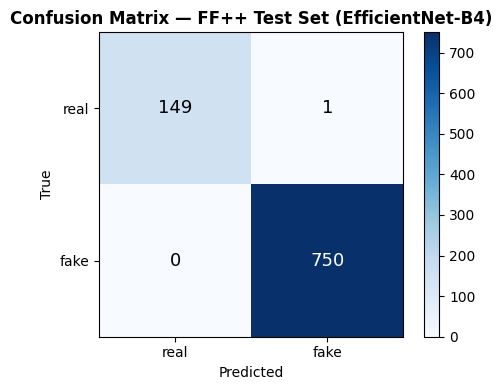

In [ ]:
print("Classification Report — FF++ Test Set (EfficientNet-B4):\n")
print(classification_report(effnet_ffpp_m["y_true"], effnet_ffpp_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(effnet_ffpp_m["y_true"], effnet_ffpp_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — FF++ Test Set (EfficientNet-B4)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "17_effnetb4_ffpp_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

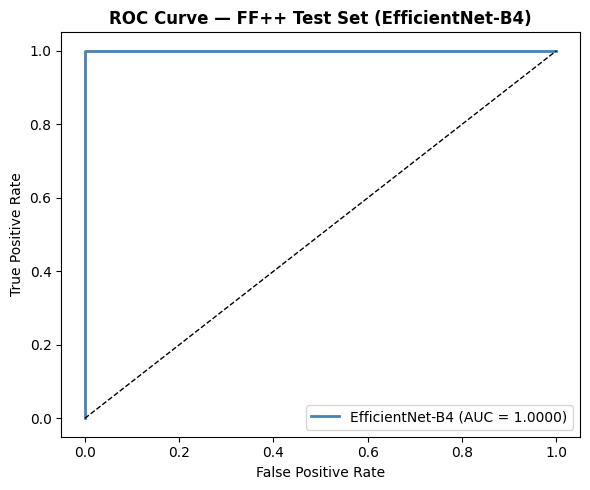

In [ ]:
fpr, tpr, _ = roc_curve(effnet_ffpp_m["y_true"], effnet_ffpp_m["y_prob"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"EfficientNet-B4 (AUC = {effnet_ffpp_m['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve — FF++ Test Set (EfficientNet-B4)", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "17b_effnetb4_ffpp_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Load previously saved Celeb-DF v2 results
with open(MODEL_DIR / "efficientnet_b4_celebdf_results.json", "r") as f:
    effnet_celebdf_m = json.load(f)

print("Celeb-DF v2 results loaded from Drive.")
print(f"\nCeleb-DF v2 Results:")
print(f"  Loss      : {effnet_celebdf_m['loss']:.4f}")
print(f"  Accuracy  : {effnet_celebdf_m['acc']:.4f}")
print(f"  Precision : {effnet_celebdf_m['precision']:.4f}")
print(f"  Recall    : {effnet_celebdf_m['recall']:.4f}")
print(f"  F1-Score  : {effnet_celebdf_m['f1']:.4f}")
print(f"  AUC       : {effnet_celebdf_m['auc']:.4f}")

gen_gap = effnet_ffpp_m["auc"] - effnet_celebdf_m["auc"]
print(f"\nGeneralization Gap (Δgen AUC) : {gen_gap:.4f}")
print(f"  FF++ AUC     : {effnet_ffpp_m['auc']:.4f}")
print(f"  Celeb-DF AUC : {effnet_celebdf_m['auc']:.4f}")

Celeb-DF v2 results loaded from Drive.

Celeb-DF v2 Results:
  Loss      : 1.2306
  Accuracy  : 0.6405
  Precision : 0.9771
  Recall    : 0.5978
  F1-Score  : 0.7418
  AUC       : 0.8401

Generalization Gap (Δgen AUC) : 0.1599
  FF++ AUC     : 1.0000
  Celeb-DF AUC : 0.8401


Classification Report — Celeb-DF v2 (EfficientNet-B4):

              precision    recall  f1-score   support

        real       0.26      0.91      0.41       890
        fake       0.98      0.60      0.74      5639

    accuracy                           0.64      6529
   macro avg       0.62      0.75      0.58      6529
weighted avg       0.88      0.64      0.70      6529



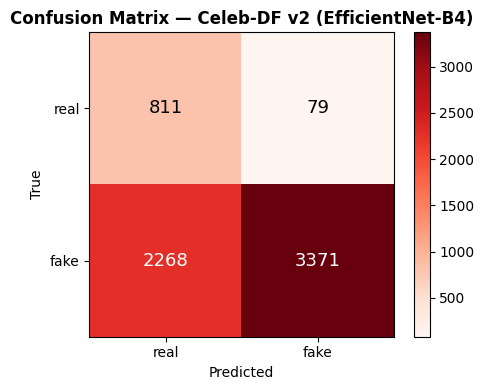

In [ ]:
print("Classification Report — Celeb-DF v2 (EfficientNet-B4):\n")
print(classification_report(effnet_celebdf_m["y_true"], effnet_celebdf_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(effnet_celebdf_m["y_true"], effnet_celebdf_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Reds")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — Celeb-DF v2 (EfficientNet-B4)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "18_effnetb4_celebdf_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

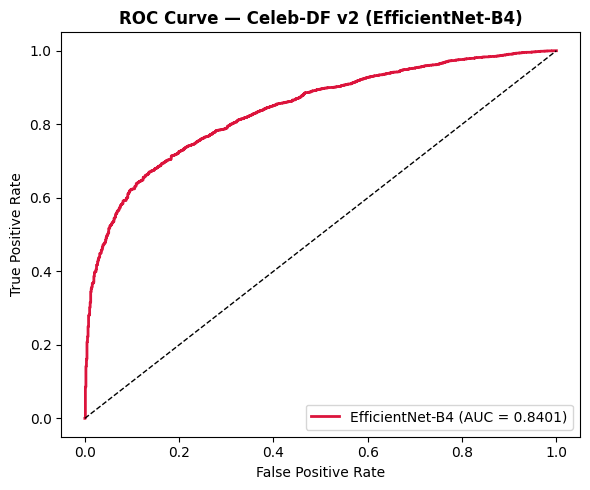

Generalization Gap (Δgen AUC) : 0.1599
  FF++ AUC     : 1.0000
  Celeb-DF AUC : 0.8401


In [ ]:
fpr, tpr, _ = roc_curve(effnet_celebdf_m["y_true"], effnet_celebdf_m["y_prob"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="crimson", lw=2,
        label=f"EfficientNet-B4 (AUC = {effnet_celebdf_m['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve — Celeb-DF v2 (EfficientNet-B4)", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "18b_effnetb4_celebdf_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

gen_gap = effnet_ffpp_m["auc"] - effnet_celebdf_m["auc"]
print(f"Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print(f"  FF++ AUC     : {effnet_ffpp_m['auc']:.4f}")
print(f"  Celeb-DF AUC : {effnet_celebdf_m['auc']:.4f}")

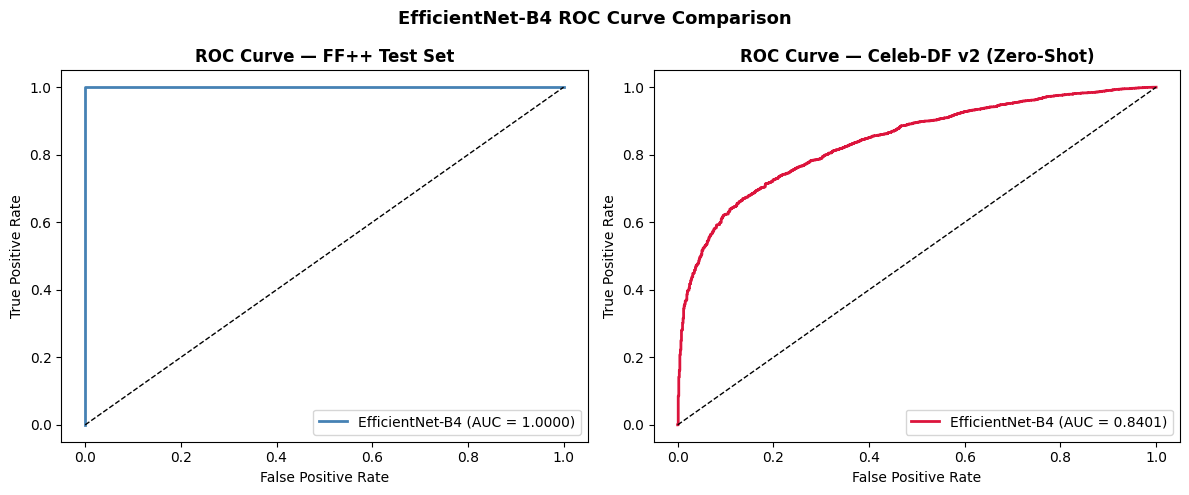

In [ ]:
fpr_ff, tpr_ff, _ = roc_curve(effnet_ffpp_m["y_true"], effnet_ffpp_m["y_prob"])
fpr_cd, tpr_cd, _ = roc_curve(effnet_celebdf_m["y_true"], effnet_celebdf_m["y_prob"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_ff, tpr_ff, color="steelblue", lw=2,
             label=f"EfficientNet-B4 (AUC = {effnet_ffpp_m['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve — FF++ Test Set", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(fpr_cd, tpr_cd, color="crimson", lw=2,
             label=f"EfficientNet-B4 (AUC = {effnet_celebdf_m['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve — Celeb-DF v2 (Zero-Shot)", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.suptitle("EfficientNet-B4 ROC Curve Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "19_effnetb4_roc_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("=" * 55)
print("EFFICIENTNET-B4 — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"\n{'Metric':<20} {'FF++ Test':>12} {'Celeb-DF v2':>12} {'Gap':>10}")
print("-" * 55)
for m, ff, cd in [
    ("Accuracy",  effnet_ffpp_m["acc"],  effnet_celebdf_m["acc"]),
    ("Precision", effnet_ffpp_m["precision"], effnet_celebdf_m["precision"]),
    ("Recall",    effnet_ffpp_m["recall"],    effnet_celebdf_m["recall"]),
    ("F1-Score",  effnet_ffpp_m["f1"],   effnet_celebdf_m["f1"]),
    ("AUC",       effnet_ffpp_m["auc"],  effnet_celebdf_m["auc"]),
]:
    print(f"  {m:<18} {ff:>12.4f} {cd:>12.4f} {ff-cd:>+10.4f}")
print(f"\n  Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print("=" * 55)

EFFICIENTNET-B4 — FINAL RESULTS SUMMARY

Metric                  FF++ Test  Celeb-DF v2        Gap
-------------------------------------------------------
  Accuracy                 0.9989       0.6405    +0.3584
  Precision                0.9987       0.9771    +0.0216
  Recall                   1.0000       0.5978    +0.4022
  F1-Score                 0.9993       0.7418    +0.2576
  AUC                      1.0000       0.8401    +0.1599

  Generalization Gap (Δgen AUC) : 0.1599
